# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [1]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

In [2]:
pip install citipy

Note: you may need to restart the kernel to use updated packages.


### Generate the Cities List by Using the `citipy` Library

In [3]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 592


## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [4]:
# Set the API base URL
#url = f"https://api.openweathermap.org/data/2.5/weather?units=Imperial&APPID={"weather_api_key"}
url = f"http://api.openweathermap.org/data/2.5/weather?units=Imperial&APPID={weather_api_key}"
#units = "metric"
#query url
#query_url = f"{url}appid={weather_api_key}&units={units}&q="
# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = url + "&q=" + city

    # Log the url, record, and set numbers
    #print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))
    print(f"Processing Record {record_count} of Set {set_count} | {city}")
    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        city_weather = requests.get(city_url).json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds =city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | margaret river
Processing Record 2 of Set 1 | lyozna
Processing Record 3 of Set 1 | bethel
Processing Record 4 of Set 1 | cidreira
Processing Record 5 of Set 1 | praia da vitoria
Processing Record 6 of Set 1 | san martin
Processing Record 7 of Set 1 | longyearbyen
Processing Record 8 of Set 1 | iqaluit
Processing Record 9 of Set 1 | udachny
Processing Record 10 of Set 1 | port-aux-francais
Processing Record 11 of Set 1 | kristiansund
Processing Record 12 of Set 1 | yellowknife
Processing Record 13 of Set 1 | bredasdorp
Processing Record 14 of Set 1 | vorgashor
Processing Record 15 of Set 1 | lompoc
Processing Record 16 of Set 1 | solnechnyy
Processing Record 17 of Set 1 | grytviken
Processing Record 18 of Set 1 | keflavik
Processing Record 19 of Set 1 | college
Processing Record 20 of Set 1 | adamstown
Processing Record 21 of Set 1 | pindushi
Processing Record 22 of Set 1 | tharangambadi
Processi

In [5]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          567
Lat           567
Lng           567
Max Temp      567
Humidity      567
Cloudiness    567
Wind Speed    567
Country       567
Date          567
dtype: int64

In [6]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,margaret river,-33.9500,115.0667,54.91,73,9,7.87,AU,1730070131
1,lyozna,55.0249,30.7956,40.96,86,1,4.97,BY,1730070132
2,bethel,41.3712,-73.4140,49.10,40,44,3.49,US,1730069986
3,cidreira,-30.1811,-50.2056,65.64,62,0,14.07,BR,1730070055
4,praia da vitoria,38.7333,-27.0667,64.65,77,75,8.05,PT,1730070135


In [7]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [8]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,margaret river,-33.9500,115.0667,54.91,73,9,7.87,AU,1730070131
1,lyozna,55.0249,30.7956,40.96,86,1,4.97,BY,1730070132
2,bethel,41.3712,-73.4140,49.10,40,44,3.49,US,1730069986
3,cidreira,-30.1811,-50.2056,65.64,62,0,14.07,BR,1730070055
4,praia da vitoria,38.7333,-27.0667,64.65,77,75,8.05,PT,1730070135


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

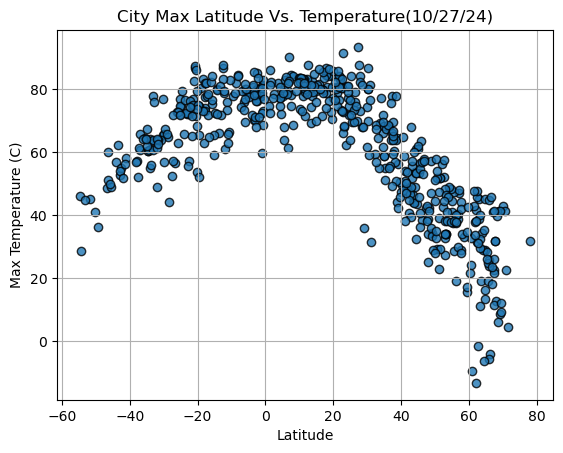

In [9]:
# Build scatter plot for latitude vs. temperature
lats = city_data_df["Lat"]
max_temps = city_data_df["Max Temp"]
plt.scatter(lats, max_temps, edgecolor="black", linewidth = 1, marker = "o", alpha = 0.8, label = "Cities" )
# Incorporate the other graph properties
plt.title("City Max Latitude Vs. Temperature(%s)" % time.strftime("%x"))
plt.ylabel("Max Temperature (C)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

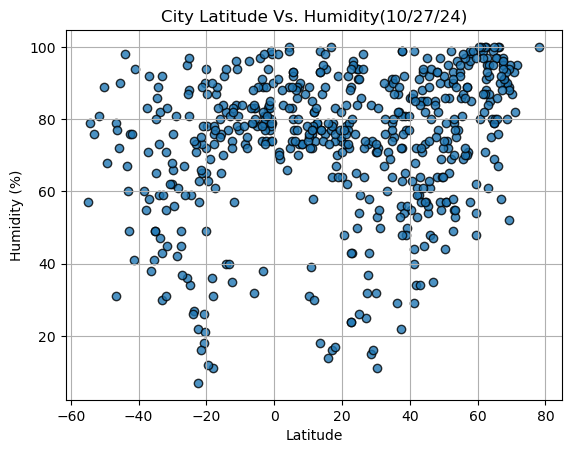

In [10]:
# Build the scatter plots for latitude vs. humidity
humidity = city_data_df["Humidity"]
plt.scatter(lats, humidity, edgecolor="black", linewidth = 1, marker = "o", alpha = 0.8, label = "Cities" )

# Incorporate the other graph properties
plt.title("City Latitude Vs. Humidity(%s)" % time.strftime("%x"))
plt.ylabel("Humidity (%)")
plt.xlabel("Latitude")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

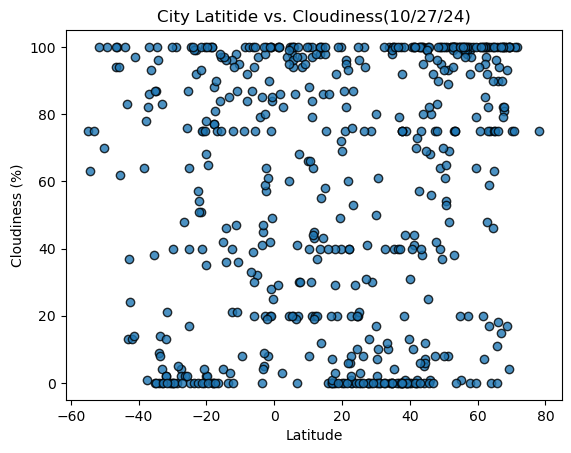

In [11]:
# Build the scatter plots for latitude vs. cloudiness
cloudiness  = city_data_df["Cloudiness"]
plt.scatter(lats, cloudiness, edgecolor = "black", alpha = 0.8, marker = "o", label = "Cities", linewidth = 1)
# Incorporate the other graph properties
plt.title("City Latitide vs. Cloudiness(%s)" % time.strftime("%x"))
plt.ylabel("Cloudiness (%)")
plt.xlabel("Latitude")

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

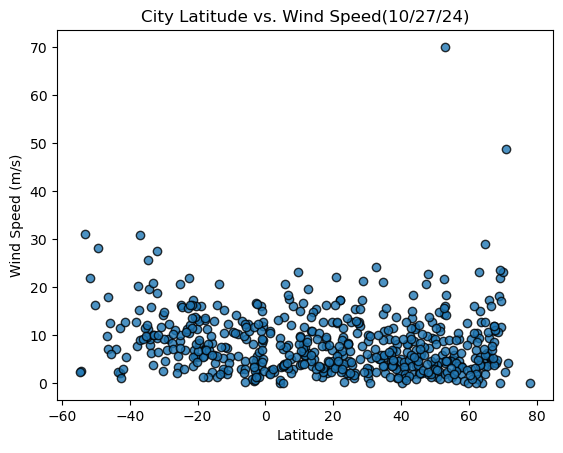

In [12]:
# Build the scatter plots for latitude vs. wind speed
wind_speed = city_data_df["Wind Speed"]
plt.scatter(lats, wind_speed, edgecolor = "black", linewidth = 1, alpha = 0.8, marker = "o", label = "Cities")

# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed(%s)" % time.strftime("%x"))
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Latitude")

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [13]:
# Define a function to create Linear Regression plots
def plot_linear_regression(x_values,y_values,title,text_coordinates):
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    regress_values = x_values * slope + intercept
    line_eq = "y = " + str(round(slope, 2)) + " x + " + str(round(intercept, 2))
    
    plt.scatter(x_values, y_values)
    plt.plot(x_values, regress_values, "r-")
    #plt.title(title)
    #plt.xlabel("Latitude")
    #plt.ylabel("Max Temp")
    plt.annotate(line_eq, text_coordinates, fontsize=15, color="red")
    print(f"The r-squared is: {rvalue**2}")
    plt.show()

In [14]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
Latitude = city_data_df["Lat"]
#northern_hemi_data = pd.DataFrame(city_data_df)
northern_hemi_df = city_data_df[city_data_df["Lat"] >= 0]
# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,lyozna,55.0249,30.7956,40.96,86,1,4.97,BY,1730070132
2,bethel,41.3712,-73.4140,49.10,40,44,3.49,US,1730069986
4,praia da vitoria,38.7333,-27.0667,64.65,77,75,8.05,PT,1730070135
6,longyearbyen,78.2186,15.6401,31.84,100,75,0.00,SJ,1730070137
7,iqaluit,63.7506,-68.5145,19.13,85,75,12.66,CA,1730070074


In [15]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
Latitude = city_data_df["Lat"]
#southern_hemi_data = pd.DataFrame(city_data_df)
southern_hemi_df = city_data_df[city_data_df["Lat"] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,margaret river,-33.9500,115.0667,54.91,73,9,7.87,AU,1730070131
3,cidreira,-30.1811,-50.2056,65.64,62,0,14.07,BR,1730070055
5,san martin,-33.0810,-68.4681,77.79,30,0,3.65,AR,1730069918
9,port-aux-francais,-49.3500,70.2167,36.19,68,100,28.07,TF,1730070125
12,bredasdorp,-34.5322,20.0403,60.40,86,100,25.55,ZA,1730070144


###  Temperature vs. Latitude Linear Regression Plot

The r-squared is: 0.7611014581255906


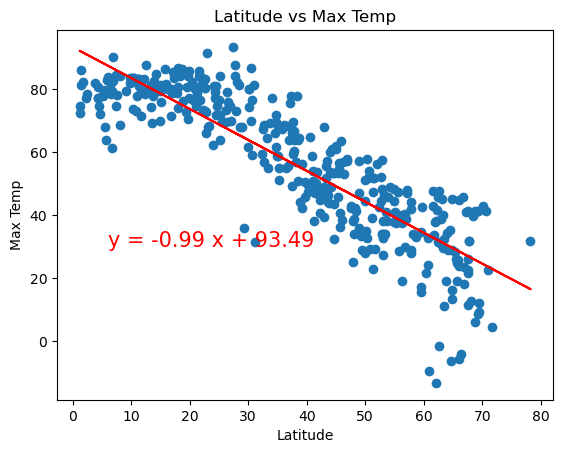

In [16]:
# Linear regression on Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Max Temp"]

plt.title("Latitude vs Max Temp")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plot_linear_regression(x_values, y_values, "Latitude vs Max Temp", (6, 30))

The r-squared is: 0.5501871415612611


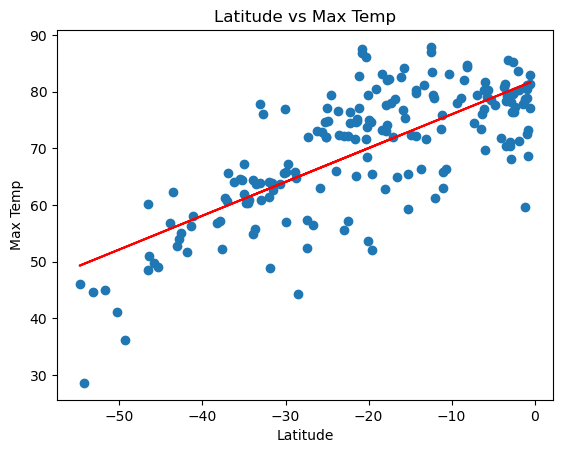

In [17]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Max Temp"]

plt.title("Latitude vs Max Temp")
plt.xlabel("Latitude")
plt.ylabel("Max Temp")
plot_linear_regression(x_values, y_values, "Latitude vs Max Temp", (-30, 20))

**Discussion about the linear relationship:** About 55% of the variation in the dependent variable (the outcome) can be explained by the independent variable(s) from this linear regression model. This indicates a moderate level of correlation between the predictors and the outcome.

### Humidity vs. Latitude Linear Regression Plot

The r-squared is: 0.03463701414443523


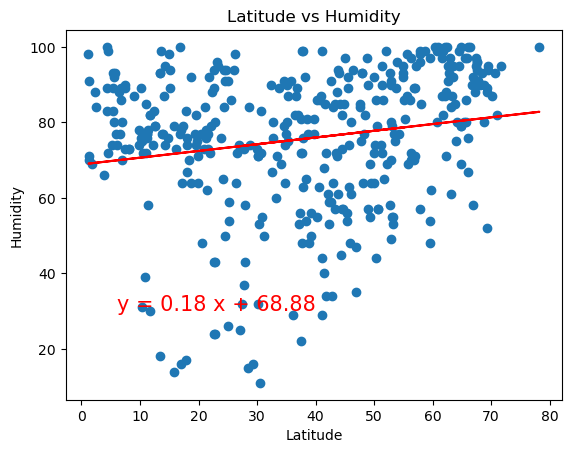

In [18]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

plt.title("Latitude vs Humidity")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plot_linear_regression(x_values, y_values, "Latitude vs Humidity", (6, 30))

The r-squared is: 0.06454148834087606


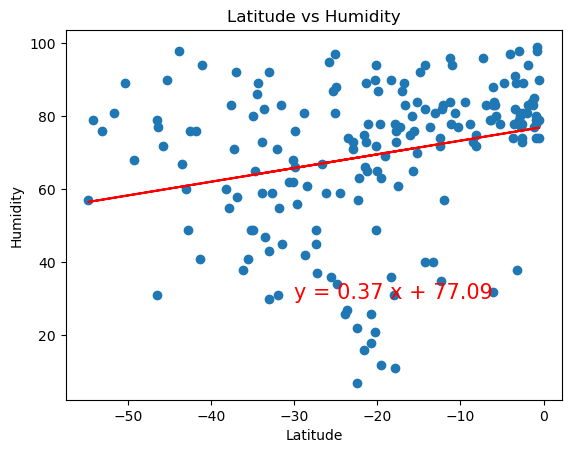

In [19]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Humidity"]

plt.title("Latitude vs Humidity")
plt.xlabel("Latitude")
plt.ylabel("Humidity")
plot_linear_regression(x_values, y_values, "Latitude vs Humidity", (-30, 30))

**Discussion about the linear relationship:** The result bout 6.5% indicates that there is a very weak relationship between the variables.

### Cloudiness vs. Latitude Linear Regression Plot

The r-squared is: 0.0510829935275597


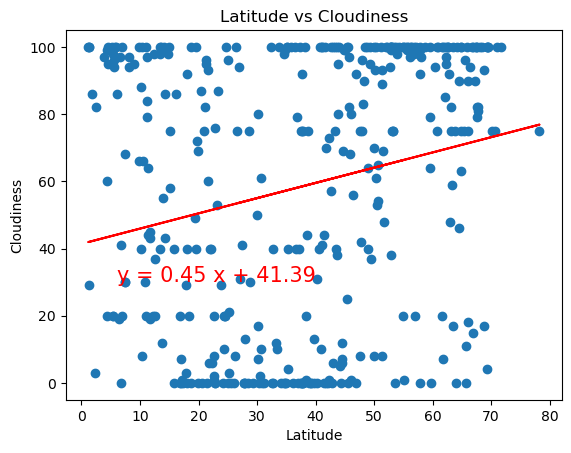

In [20]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Cloudiness"]

plt.title("Latitude vs Cloudiness")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plot_linear_regression(x_values, y_values, "Latitude vs Cloudiness", (6, 30))

The r-squared is: 0.0017095226784085969


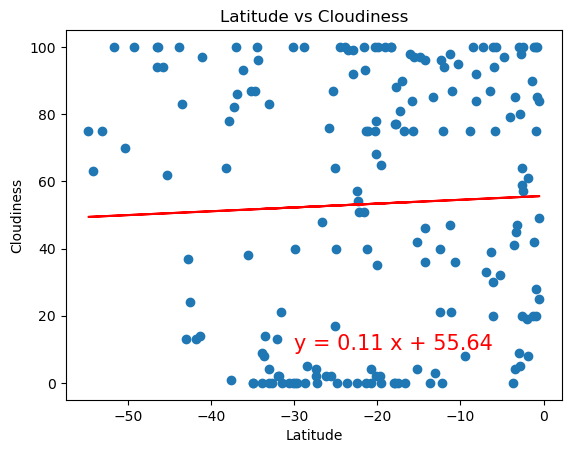

In [21]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Cloudiness"]

plt.title("Latitude vs Cloudiness")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness")
plot_linear_regression(x_values, y_values, "Latitude vs Cloudiness", (-30, 10))

**Discussion about the linear relationship:** The extremely low R-squared value explain that there is almost no relationship between the variables.

### Wind Speed vs. Latitude Linear Regression Plot

The r-squared is: 0.0017676796683297963


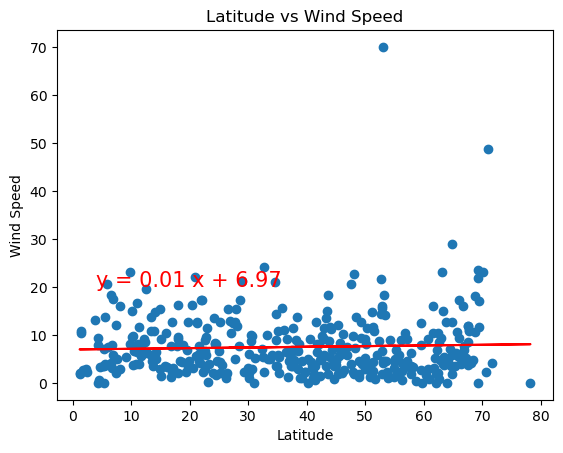

In [22]:
# Northern Hemisphere
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Wind Speed"]

plt.title("Latitude vs Wind Speed")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plot_linear_regression(x_values, y_values, "Latitude vs Cloudiness", (4, 20))

The r-squared is: 0.09474524138086328


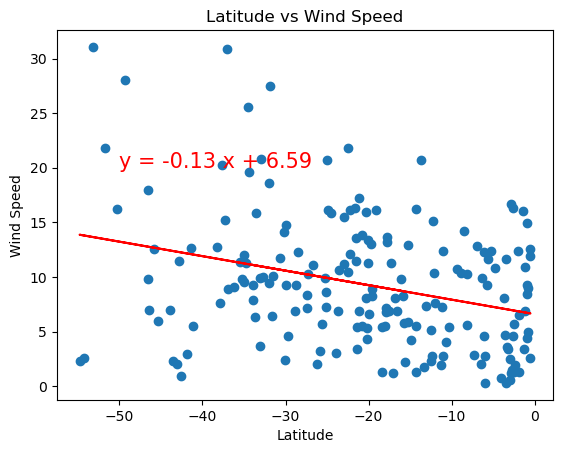

In [23]:
# Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Wind Speed"]

plt.title("Latitude vs Wind Speed")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed")
plot_linear_regression(x_values, y_values, "Latitude vs Cloudiness", (-50, 20))

**Discussion about the linear relationship:** The result bout 9.4% indicates that there is a very weak relationship between the variables.